<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/Proyecto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bioseñales y Sistemas
##Segundo Proyecto
###Integrantes:
- Juan Sebastian Daza Betancourt
- Juan Jose Lopez Cuadros


#1. Consulta

### Índices del EEG para mejorar la clasificación de estados en BCI
Los sistemas BCI no invasivos basados en EEG dependen de la capacidad para distinguir, de forma confiable, entre diferentes estados mentales. La densidad espectral de potencia (PSD), trabajada en el proyecto anterior, es una característica ampliamente utilizada; sin embargo, la literatura reporta consistentemente que la combinación con índices en el dominio temporal, de conectividad y de complejidad mejora la separabilidad entre clases. A continuación se presentan tres índices implementables en Python que complementan la extracción de características basada en PSD.

###1.1 Parámetros de Hjorth – Movilidad (Hjorth Mobility)
- Definición y fundamento matemático

Los parámetros de Hjorth fueron propuestos por Bo Hjorth en 1970 como descriptores estadísticos de las propiedades de una señal en el dominio temporal, sin necesidad de transformadas espectrales. El conjunto incluye tres medidas: Actividad, Movilidad y Complejidad. La Movilidad se define como la raíz cuadrada del cociente entre la varianza de la primera derivada de la señal y la varianza de la señal misma.

Esta expresión es proporcional a la desviación estándar del espectro de potencia, por lo que constituye una estimación de la frecuencia media de la señal calculada íntegramente en el dominio temporal. Su bajo costo computacional la hace especialmente adecuada para sistemas en tiempo real.

###Comportamiento esperado frente a las condiciones del proyecto

- Reposo: Ambos hemisferios mantienen un ritmo basal lento; la Movilidad en C3 y C4 es baja y simétrica.
- Imaginación mano derecha: El hemisferio izquierdo (C3) procesa la intención motora contralateral. Su señal se vuelve más rápida e irregular, elevando la Movilidad en C3, mientras C4 permanece en valores basales.
- Imaginación mano izquierda: El patrón se invierte, la Movilidad en C4 aumenta y C3 se mantiene tranquilo.

###Implementación en Python

El índice se calcula con NumPy sin librerías externas:

diff_signal = np.diff(epoch_signal, axis=-1)

hjorth_mobility = np.sqrt(np.var(diff_signal, axis=-1) / np.var(epoch_signal, axis=-1))

###1.2 Valor de Bloqueo de Fase (PLV – Phase Locking Value)

- Definición y fundamento matemático

El PLV cuantifica la sincronización de fase entre dos señales. Para cada época se extrae la fase instantánea de cada canal mediante la transformada de Hilbert, y se calcula el módulo del promedio temporal del exponencial complejo de la diferencia de fases

El resultado oscila entre 0 (fases completamente independientes) y 1 (sincronización perfecta). A diferencia de los índices que describen un canal individualmente, el PLV captura la dinámica de red entre hemisferios, lo que lo convierte en una medida de conectividad funcional.

###Comportamiento esperado frente a las condiciones del proyecto
- Reposo: Sin demanda cognitiva focalizada, ambos hemisferios oscilan de forma coordinada; el PLV entre C3 y C4 es relativamente alto.
- Imaginación motora (cualquier mano): El hemisferio encargado de planificar el movimiento interrumpe su ritmo sincronizado para ejecutar la tarea. La desincronización resultante reduce el PLV respecto al estado de reposo.

###Implementación en Python

from scipy.signal import hilbert phases = np.angle(hilbert(epoch_signal, axis=-1))

phase_diff = phases[0] - phases[1] plv = np.abs(np.mean(np.exp(1j * phase_diff)))

###1.3 Entropía Muestral (Sample Entropy – SampEn)
- Definición y fundamento matemático

La entropía muestral cuantifica la irregularidad o complejidad de una serie temporal. Fue introducida por Richman y Moorman en 2000 como corrección a la entropía aproximada (ApEn), la cual sobreestima el orden de la señal porque incluye la comparación de cada plantilla consigo misma (autocomparaciones). SampEn excluye explícitamente estas autocomparaciones, eliminando el sesgo y haciendo el estimador más consistente independientemente de la longitud de la serie

Un valor alto de SampEn indica mayor desorden o imprevisibilidad en la señal.

###Comportamiento esperado frente a las condiciones del proyecto
- Reposo: La actividad eléctrica cortical sin demanda de tarea es relativamente regular y repetitiva; SampEn toma valores bajos.
- Imaginación motora: La planificación del movimiento implica actividad cognitiva compleja que genera patrones eléctricos menos predecibles. SampEn aumenta en el canal del hemisferio activo, diferenciando además entre mano derecha (aumento en C3) e izquierda (aumento en C4).

###Implementación en Python
import antropy as ant sampen_c3 = ant.sample_entropy(epoch_signal[0])

sampen_c4 = ant.sample_entropy(epoch_signal[1])





#2. Plan de Analisis

Con base en la metodología desarrollada en el Proyecto 1 y los índices seleccionados en la consulta anterior, se propone el siguiente flujo de análisis para evidenciar diferencias entre las condiciones de reposo, imaginación de movimiento de mano derecha e imaginación de movimiento de mano izquierda.

- 2.1 Adquisición y acondicionamiento de la señal

Se parte de los archivos .EDF del conjunto de datos PhysioNet EEG Motor Movement/Imagery Dataset. Para este proyecto se seleccionan los runs de imaginación motora (R04, R08 o R12), en los cuales el sujeto imagina abrir y cerrar el puño derecho (T2) o el izquierdo (T1), con períodos de reposo entre tareas (T0).
Se aplica el mismo filtro pasa-banda (5–33 Hz) del Proyecto 1 para aislar los ritmos Mu (8–13 Hz) y Beta (13–30 Hz). Este rango elimina artefactos de baja frecuencia (movimientos oculares) y ruido muscular de alta frecuencia sin requerir un filtro Notch adicional dado que los artefactos de 60 Hz quedan fuera de la banda de interés.


- 2.2 Selección espacial de canales

Se trabaja exclusivamente con los electrodos C3 y C4, ubicados sobre la corteza motora primaria en los hemisferios izquierdo y derecho, respectivamente. La elección se fundamenta en la organización somatotópica del homúnculo de Penfield y en el principio de control contralateral: C3 refleja la actividad relacionada con la mano derecha y C4 la relacionada con la mano izquierda. La asimetría entre ambos canales es, precisamente, la firma espacial que permite discriminar las tres condiciones.
A diferencia del Proyecto 1, en este proyecto se excluye el canal Cz porque los runs seleccionados no incluyen tareas de pies y su inclusión introduciría ruido irrelevante en los índices de conectividad inter-hemisférica (PLV C3–C4).

- 2.3 Segmentación en épocas

La señal se divide en épocas de 5 segundos centradas en el evento (tmin = –1.0 s, tmax = 4.0 s) con corrección de línea base en el intervalo pre-estímulo (–1 s a 0 s). Esto permite analizar tanto el estado previo a la tarea como los 4 segundos de ejecución de la imaginación. El etiquetado sigue el mapa de anotaciones del archivo EDF: T0 → Reposo, T1 → Imaginación mano izquierda, T2 → Imaginación mano derecha.

- 2.4 Extracción de características

Para cada época y cada canal se calcularán las siguientes características, generando el dataframe descrito en el enunciado:

1.	PSD relativa en bandas Mu y Beta (heredado del Proyecto 1): estimada con el método de Welch (ventana de Hamming, 50 % de traslape). Se calcula la potencia relativa (%) en 8–13 Hz y 13–30 Hz para C3 y C4.
2.	Movilidad de Hjorth (C3 y C4): calculada en el dominio temporal a partir de la varianza de la señal y de su primera derivada discreta.
3.	Entropía Muestral (C3 y C4): calculada con la librería antropy sobre la señal filtrada de cada canal.
4.	PLV entre C3 y C4: calculado mediante la transformada de Hilbert; un único valor por época que captura la sincronización inter-hemisférica.

- 2.5 Análisis estadístico descriptivo

Para cada índice se construirán gráficas de distribución separadas por condición, lo que permite visualizar mediana, dispersión y posibles valores atípicos. Se calculan media, desviación estándar y cuartiles por condición. Se verificará si las distribuciones son simétricas o presentan sesgo, ya que esto determina el tipo de prueba estadística a aplicar. Adicionalmente, se calculará la lateralidad (diferencia o cociente C3–C4) de cada índice como característica derivada que resume la asimetría hemisférica en un solo número.

- 2.6 Hipótesis estadísticas y pruebas de significancia

Dado que las épocas de un mismo sujeto no son independientes entre sí, se operará a nivel de sujeto (promediando los índices por condición y sujeto) antes de aplicar las pruebas. La selección entre prueba paramétrica y no paramétrica dependerá de la prueba de normalidad de Shapiro-Wilk sobre cada distribución (α = 0.05).

###Hipótesis 1 – Diferencia entre reposo e imaginación motora (PLV)
-	H₀: No existe diferencia en el PLV C3–C4 entre el estado de reposo y los estados de imaginación motora.
-	H₁: El PLV es significativamente mayor en reposo que durante la imaginación motora, dado que la planificación del movimiento desacopla la sincronía inter-hemisférica.

Pruebas:
- t de Student pareada (si distribución normal) o Wilcoxon de rangos con signo (si no normal). Comparación reposo vs. cada clase de imaginación por separado.

###Hipótesis 2 – Lateralidad hemisférica en Movilidad de Hjorth y SampEn
•	H₀: No existe diferencia en la asimetría C3–C4 (Movilidad o SampEn) entre las tres condiciones.
•	H₁: La imaginación de mano derecha produce mayor Movilidad y SampEn en C3 que en C4, y la imaginación de mano izquierda produce el patrón contrario.
Prueba sugerida: ANOVA de una vía con corrección de Bonferroni (si normal) o Kruskal-Wallis con pruebas post hoc de Dunn (si no normal) para comparar las tres condiciones simultáneamente.

- 2.7 Estrategia de clasificación

Se seleccionarán los índices con mayor poder discriminante según los resultados del análisis estadístico (se priorizan aquellos con mayor diferencia de medias relativa entre condiciones y menor varianza dentro de clase). Con dichos índices se construirá un vector de características por época.

- Partición de datos: K-Fold estratificado (K = 5 o K = 10) a nivel de época, garantizando que cada pliegue contenga proporciones similares de las tres clases.
- Arquitecturas a comparar: Se evaluarán al menos tres modelos:
 1. Support Vector Machine (SVM) con kernel RBF
 2. Extreme Gradient Boosting (XGBoost)
 3. Red Neuronal Artificial multicapa (MLP).

 Para cada modelo se reportará la exactitud promedio, la desviación estándar entre pliegues y la matriz de confusión agregada.
- Métrica de evaluación: Exactitud balanceada (balanced accuracy), dado el desbalance entre clases (Reposo: ~1531 épocas vs. ~828 y ~808 de imaginación).


#3. Programación

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 31.7 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [1]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
!pip install antropy

In [ ]:
!aws s3 sync --no-sign-request s3://openneuro.org/ds004362 /content/dataset_eeg

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy import stats
from IPython.display import display
import antropy as ant
from scipy.signal import hilbert

Archivos encontrados para el experimento (*R04.edf): 109

Generando gráficas de control temporal y espectral para S024...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


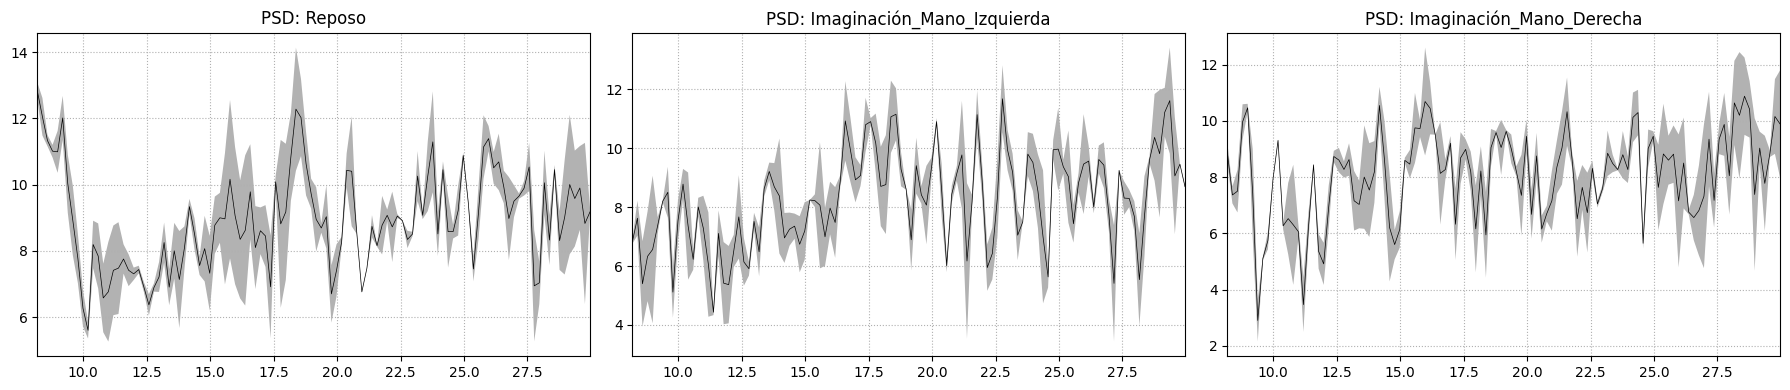

/tmp/ipykernel_3283/1984895407.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)



--- ESTRUCTURA FINAL DEL DATAFRAME ---


,Registro,Tarea,PSD_Mu_C3,PSD_Mu_C4,PSD_Beta_C3,PSD_Beta_C4,Hjorth_Mob_C3,Hjorth_Mob_C4,SampEn_C3,SampEn_C4,PLV_C3_C4
0,S024,Reposo,23.795885,24.542820,76.204115,75.457180,0.862278,0.827082,1.494091,1.466219,0.413358
1,S024,Reposo,14.855385,13.162302,85.144615,86.837698,0.837889,0.750911,1.557715,1.470296,0.477681
2,S024,Reposo,15.638026,20.532942,84.361974,79.467058,0.797896,0.728273,1.551050,1.434674,0.565626
3,S024,Reposo,17.695729,28.582697,82.304271,71.417303,0.735537,0.663901,1.421695,1.335620,0.591080
4,S024,Reposo,18.919092,23.631701,81.080908,76.368299,0.853518,0.794885,1.544864,1.438806,0.534811
5,S024,Reposo,24.211467,14.684909,75.788533,85.315091,0.838121,0.844993,1.389893,1.389738,0.551995
6,S024,Reposo,12.543785,15.046604,87.456215,84.953396,0.876478,0.851467,1.475749,1.463928,0.388783
7,S024,Reposo,18.335925,24.267139,81.664075,75.732861,0.809482,0.775477,1.477041,1.439669,0.455102
8,S024,Reposo,34.856159,29.124664,65.143841,70.875336,0.807529,0.773188,1.540445,1.488745,0.586567
9,S024,Reposo,11.167321,16.520456,88.832679,83.479544,0.835179,0.812217,1.509281,1.497641,0.492311


In [5]:


# --- CONFIGURACIÓN DEL PROYECTO 2 ---
ruta_dataset = Path("/content/dataset_eeg")

# Seleccionamos las tareas de imaginación de manos (Runs 4, 8 o 12)
run_seleccionado = '*R04.edf'
rutas_runs = list(ruta_dataset.rglob(run_seleccionado))

print(f"Archivos encontrados para el experimento ({run_seleccionado}): {len(rutas_runs)}")

filas_dataset = []
grafica_mostrada = False

task_mapping = {
    'T0': 'Reposo',
    'T1': 'Imaginación_Mano_Izquierda',
    'T2': 'Imaginación_Mano_Derecha'
}

for archivo_path in rutas_runs:
    sujeto_id = archivo_path.stem.split('R')[0]

    try:
        raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)
        mapping = {ch: ch.replace('.', '').strip() for ch in raw.ch_names}
        raw.rename_channels(mapping)

        # ELIMINAMOS Cz - Solo nos quedamos con C3 y C4
        canales_interes = ['C3', 'C4']
        raw.pick(canales_interes)

        # Filtro pasabanda
        raw.filter(l_freq=5.0, h_freq=33.0, verbose=False)

        events, event_id_map = mne.events_from_annotations(
            raw,
            event_id={'T0': 1, 'T1': 2, 'T2': 3},
            verbose=False
        )

        epochs = mne.Epochs(raw, events, event_id=event_id_map, tmin=-1.0, tmax=4.0,
                            baseline=(None, 0), preload=True, verbose=False)

        # --- VISUALIZACIÓN DE CONTROL (SOLO PRIMER PACIENTE) ---
        if not grafica_mostrada:
            print(f"\nGenerando gráficas de control temporal y espectral para {sujeto_id}...")
            fig, ax = plt.subplots(1, 3, figsize=(18, 4))
            for idx, (annot_key, task_name) in enumerate(task_mapping.items()):
                if annot_key in epochs.event_id:
                    epochs[annot_key].compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False).plot(
                        average=True, axes=ax[idx], show=False
                    )
                    ax[idx].set_title(f'PSD: {task_name}')
            plt.tight_layout()
            plt.show()
            grafica_mostrada = True

        # --- PROCESAMIENTO ÉPOCA POR ÉPOCA ---
        for annot_key, task_name in task_mapping.items():
            if annot_key in epochs.event_id:

                sub_epochs = epochs[annot_key]
                data_signals = sub_epochs.get_data()  # Shape: (num_epocas, 2_canales, num_tiempos)

                psd_object = sub_epochs.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)
                psd_data = psd_object.get_data()  # Shape: (num_epocas, 2_canales, num_frecuencias)
                frecuencias = psd_object.freqs

                idx_mu = np.where((frecuencias >= 8.0) & (frecuencias <= 13.0))[0]
                idx_beta = np.where((frecuencias >= 13.1) & (frecuencias <= 30.0))[0]

                for i in range(len(sub_epochs)):

                    # CORRECCIÓN DEL ERROR DE BROADCASTING NUMPY
                    # Aislamos primero la época para evitar que NumPy cruce las dimensiones
                    psd_epoch = psd_data[i] # Shape: (2, num_frecuencias)

                    # 1. PSD RELATIVA
                    pot_mu = np.sum(psd_epoch[:, idx_mu], axis=-1)
                    pot_beta = np.sum(psd_epoch[:, idx_beta], axis=-1)
                    pot_total = np.sum(psd_epoch, axis=-1)

                    rel_mu = (pot_mu / pot_total) * 100
                    rel_beta = (pot_beta / pot_total) * 100

                    # Señal en el dominio del tiempo (0 = C3, 1 = C4)
                    epoch_signal = data_signals[i]

                    # 2. MOVILIDAD DE HJORTH
                    diff_signal = np.diff(epoch_signal, axis=-1)
                    var_raw = np.var(epoch_signal, axis=-1)
                    var_diff = np.var(diff_signal, axis=-1)
                    hjorth_mobility = np.sqrt(var_diff / var_raw)

                    # 3. ENTROPÍA MUESTRAL (SampEn) - Solo C3 y C4
                    sampen_c3 = ant.sample_entropy(epoch_signal[0])
                    sampen_c4 = ant.sample_entropy(epoch_signal[1])

                    # 4. VALOR DE BLOQUEO DE FASE (PLV C3-C4)
                    phases = np.angle(hilbert(epoch_signal, axis=-1))
                    phase_diff = phases[0] - phases[1]
                    plv_c3_c4 = np.abs(np.mean(np.exp(1j * phase_diff)))

                    # --- ORGANIZACIÓN DEL DATAFRAME ---
                    filas_dataset.append({
                        'Registro': sujeto_id,
                        'Tarea': task_name,

                        'PSD_Mu_C3': rel_mu[0],
                        'PSD_Mu_C4': rel_mu[1],

                        'PSD_Beta_C3': rel_beta[0],
                        'PSD_Beta_C4': rel_beta[1],

                        'Hjorth_Mob_C3': hjorth_mobility[0],
                        'Hjorth_Mob_C4': hjorth_mobility[1],

                        'SampEn_C3': sampen_c3,
                        'SampEn_C4': sampen_c4,

                        'PLV_C3_C4': plv_c3_c4
                    })

    except Exception as e:
        print(f"  -> Error procesando el sujeto {sujeto_id}: {e}")

# --- CREACIÓN DEL DATAFRAME FINAL ---
print("\n--- ESTRUCTURA FINAL DEL DATAFRAME ---")
df_resultados = pd.DataFrame(filas_dataset)
display(df_resultados.head(10))

In [6]:
# Agrupamos por Paciente (Registro) y Tarea, y calculamos el promedio
df_promediado = df_resultados.groupby(['Registro', 'Tarea']).mean().reset_index()

print("\n--- DATAFRAME PROMEDIADO POR SUJETO Y TAREA ---")
display(df_promediado)


--- DATAFRAME PROMEDIADO POR SUJETO Y TAREA ---


,Registro,Tarea,PSD_Mu_C3,PSD_Mu_C4,PSD_Beta_C3,PSD_Beta_C4,Hjorth_Mob_C3,Hjorth_Mob_C4,SampEn_C3,SampEn_C4,PLV_C3_C4
0,S001,Imaginación_Mano_Derecha,42.910721,48.582548,57.089279,51.417452,0.535458,0.545197,1.113498,1.156537,0.650746
1,S001,Imaginación_Mano_Izquierda,44.145480,42.107320,55.854520,57.892680,0.534221,0.530602,1.107187,1.151527,0.666366
2,S001,Reposo,50.213019,46.956785,49.786981,53.043215,0.541853,0.546878,1.126358,1.142299,0.642805
3,S002,Imaginación_Mano_Derecha,39.218110,37.989061,60.781890,62.010939,0.651409,0.658476,1.303385,1.287536,0.555839
4,S002,Imaginación_Mano_Izquierda,47.262638,42.075475,52.737362,57.924525,0.648672,0.646867,1.287811,1.297801,0.567378
...,...,...,...,...,...,...,...,...,...,...,...
322,S108,Imaginación_Mano_Izquierda,48.111328,51.196496,51.888672,48.803504,0.632369,0.566051,1.265271,1.174004,0.514064
323,S108,Reposo,43.128525,52.787922,56.871475,47.212078,0.624182,0.551113,1.239470,1.144689,0.512511
324,S109,Imaginación_Mano_Derecha,44.886009,47.818886,55.113991,52.181114,0.545787,0.550108,1.153663,1.065543,0.166201
325,S109,Imaginación_Mano_Izquierda,41.132004,49.426005,58.867996,50.573995,0.553782,0.546507,1.149798,1.072420,0.158258


# 4. Analisis de resultados

In [12]:
import pandas as pd

# Definimos la lista exacta de tus índices extraídos (puedes añadir o quitar de esta lista)
# Nombres tomados directamente de la estructura de tu DataFrame
indices_analisis = [
    'PSD_Mu_C3', 'PSD_Mu_C4',
    'PSD_Beta_C3', 'PSD_Beta_C4',
    'Hjorth_Mob_C3', 'Hjorth_Mob_C4',
    'SampEn_C3', 'SampEn_C4',
    'PLV_C3_C4'
]

print("=== PARÁMETROS DE ESTADÍSTICA DESCRIPTIVA POR CONDICIÓN ===")

# .describe() calcula automáticamente: media (mean), desviación estándar (std),
# valor mínimo (min), cuartiles (25%, 50%/mediana, 75%) y valor máximo (max)
tabla_descriptiva = df_promediado.groupby('Tarea')[indices_analisis].describe()

# Para que la visualización en la libreta sea limpia y legible, filtramos las métricas clave
metricas_clave = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
tabla_descriptiva_limpia = tabla_descriptiva.loc[:, (slice(None), metricas_clave)]

# Mostramos la tabla transpuesta si quieres leer los índices verticalmente (es más cómodo)
display(tabla_descriptiva_limpia)

=== PARÁMETROS DE ESTADÍSTICA DESCRIPTIVA POR CONDICIÓN ===


PSD_Mu_C3                                   \
                                 mean        std        min        25%   
Tarea                                                                    
Imaginación_Mano_Derecha    46.934689  11.565512  17.312533  39.696498   
Imaginación_Mano_Izquierda  46.797256  12.673347  15.135608  39.589064   
Reposo                      47.558828  13.285255  18.691861  38.975223   

                                                             PSD_Mu_C4  \
                                  50%        75%        max       mean   
Tarea                                                                    
Imaginación_Mano_Derecha    45.405593  55.346470  73.091735  47.505963   
Imaginación_Mano_Izquierda  47.120783  54.969073  74.861460  45.901819   
Reposo                      46.419617  56.770595  84.899373  47.452779   

                                                  ... SampEn_C4            \
                                  std        min  ...       50%       75%   
Tarea                                             ...                       
Imaginación_Mano_Derecha    13.457077  13.473092  ...  1.148610  1.233221   
Imaginación_Mano_Izquierda  12.988472  16.475244  ...  1.142947  1.259853   
Reposo                      14.082202  18.521947  ...  1.146651  1.231529   

                                     PLV_C3_C4                                \
                                 max      mean       std       min       25%   
Tarea                                                                          
Imaginación_Mano_Derecha    1.561467  0.603346  0.108889  0.166201  0.540735   
Imaginación_Mano_Izquierda  1.595954  0.608023  0.104153  0.158258  0.550095   
Reposo                      1.596922  0.592166  0.114500  0.146651  0.528271   

                                                          
                                 50%       75%       max  
Tarea                                                     
Imaginación_Mano_Derecha    0.623473  0.679018  0.785721  
Imaginación_Mano_Izquierda  0.611143  0.682356  0.807784  
Reposo                      0.612054  0.670571  0.811584  

[3 rows x 63 columns]

/tmp/ipykernel_3283/1002892532.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3283/1002892532.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3283/1002892532.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3283/1002892532.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3283/1002892532.py:30: FutureWarning: 

P

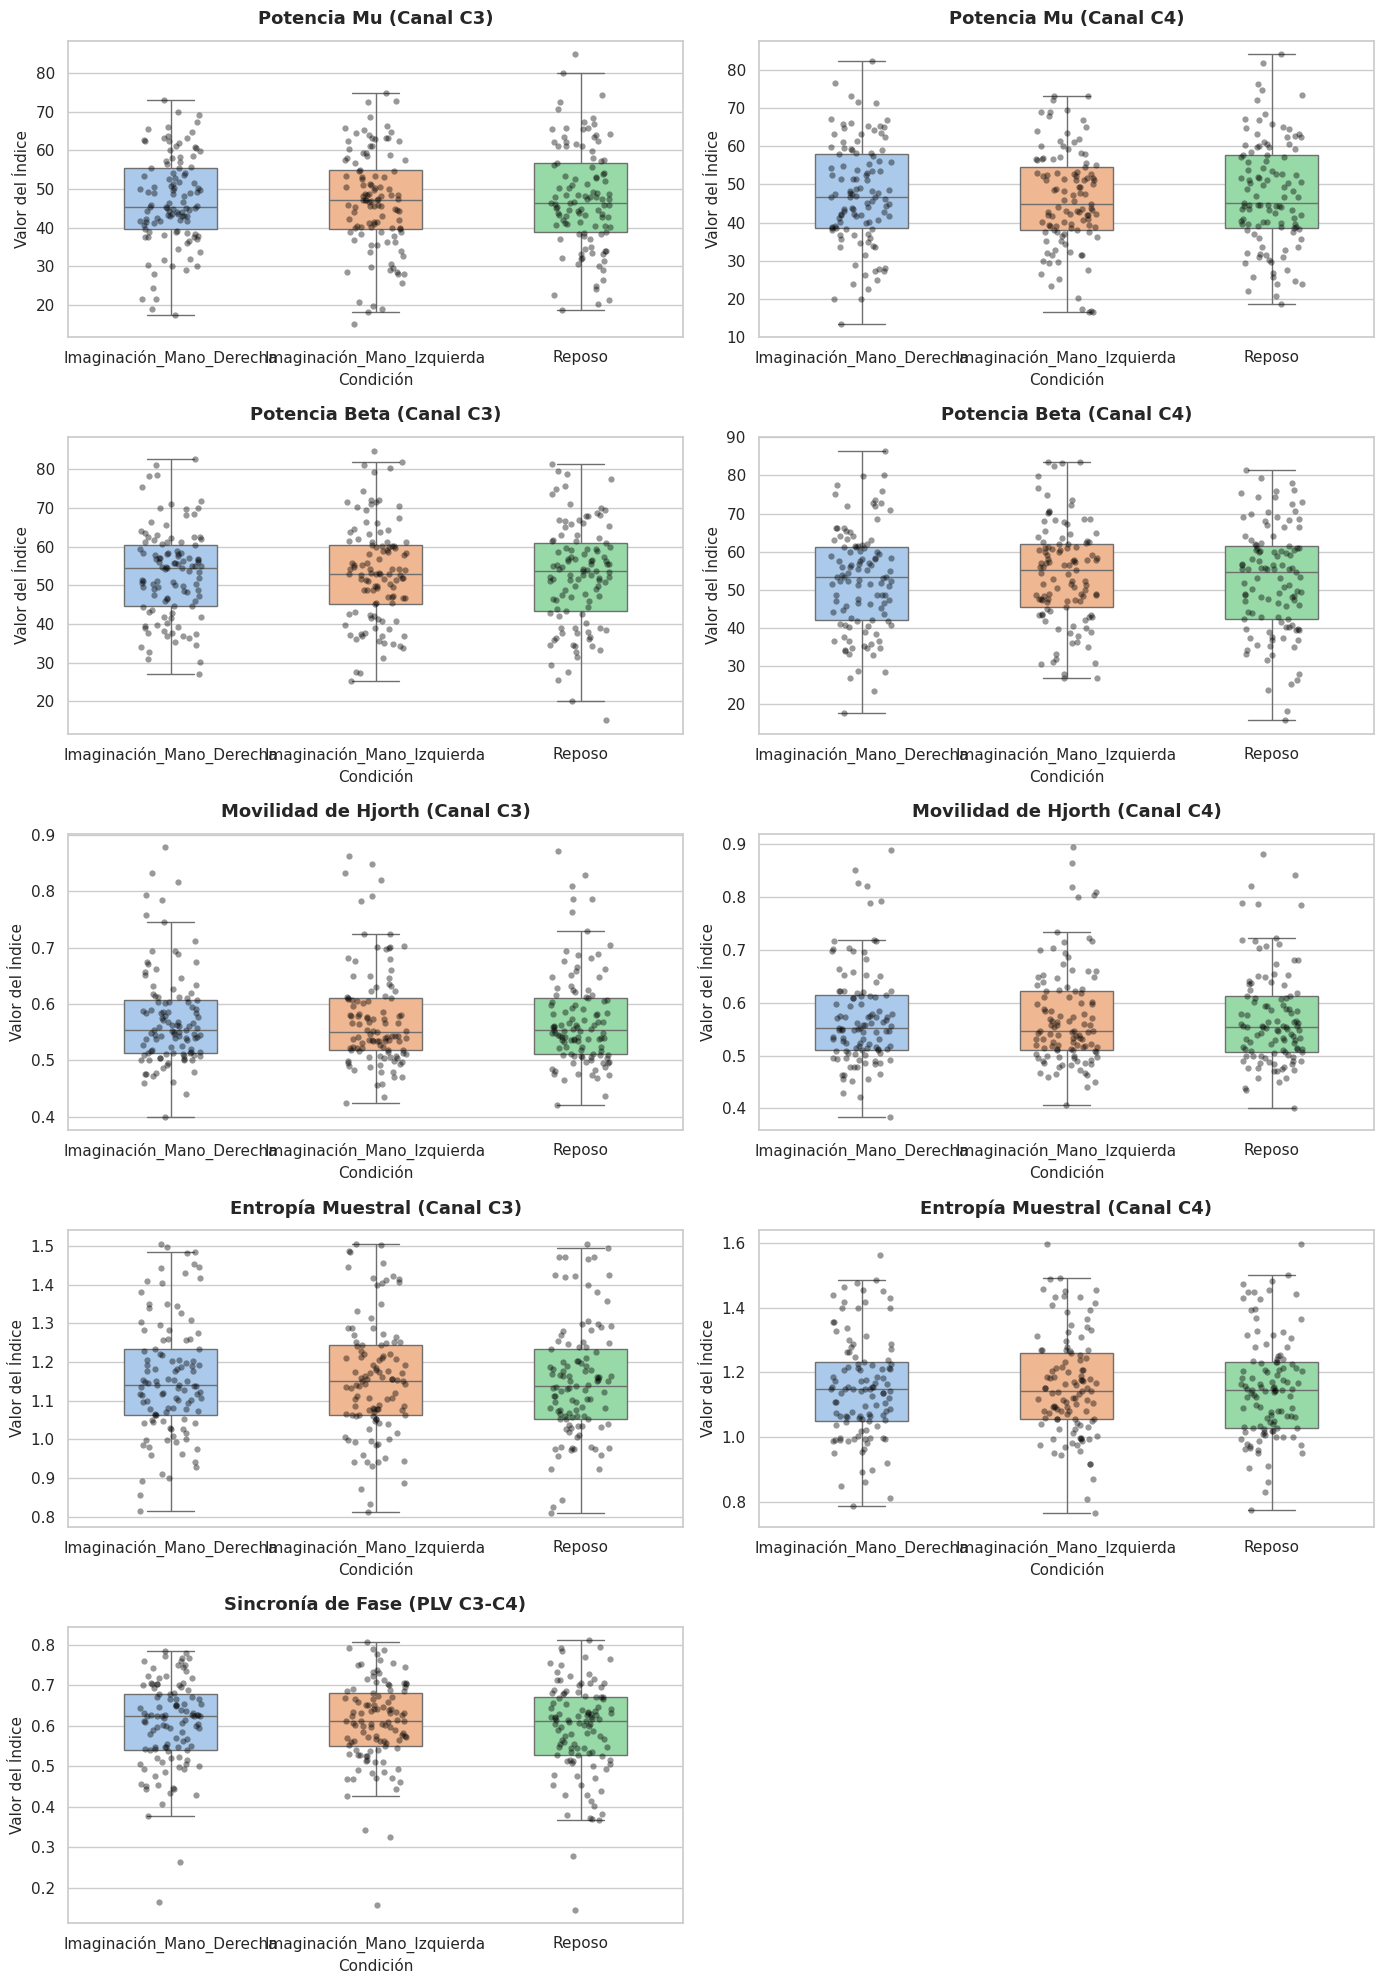

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración estética global
sns.set_theme(style="whitegrid")

# Lista con TODAS las características organizadas (C3 a un lado, C4 al otro)
indices_visuales = [
    ('PSD_Mu_C3', 'Potencia Mu (Canal C3)'),
    ('PSD_Mu_C4', 'Potencia Mu (Canal C4)'),
    ('PSD_Beta_C3', 'Potencia Beta (Canal C3)'),
    ('PSD_Beta_C4', 'Potencia Beta (Canal C4)'),
    ('Hjorth_Mob_C3', 'Movilidad de Hjorth (Canal C3)'),
    ('Hjorth_Mob_C4', 'Movilidad de Hjorth (Canal C4)'),
    ('SampEn_C3', 'Entropía Muestral (Canal C3)'),
    ('SampEn_C4', 'Entropía Muestral (Canal C4)'),
    ('PLV_C3_C4', 'Sincronía de Fase (PLV C3-C4)')
]

# 2. Creamos una figura de 4 filas x 2 columnas
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

# Aplanamos la matriz de ejes (axes) a una lista de 1 dimensión
# para que tu ciclo for funcione exactamente igual que antes
axes = axes.flatten()

for i, (columna, titulo) in enumerate(indices_visuales):

    # A. Dibujamos el Boxplot
    sns.boxplot(
        data=df_promediado,
        x='Tarea',
        y=columna,
        ax=axes[i],
        palette="pastel",
        width=0.45,
        showfliers=False # Ocultamos los outliers nativos
    )

    # B. Superponemos el Jitter (Stripplot)
    sns.stripplot(
        data=df_promediado,
        x='Tarea',
        y=columna,
        ax=axes[i],
        color="black",
        alpha=0.4,      # Transparencia
        jitter=0.15,    # Dispersión horizontal
        size=4.5        # Tamaño del punto
    )

    # C. Refinamiento de etiquetas y títulos
    axes[i].set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel('Condición', fontsize=11)
    axes[i].set_ylabel('Valor del Índice', fontsize=11)
    axes[i].tick_params(axis='x', labelsize=11)

# Ocultamos el último recuadro (el octavo) porque solo tenemos 7 índices
axes[-1].set_visible(False)

# Ajuste automático de márgenes
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

def analizar_hipotesis_bci(df):
    resultados = []

    # Estructura de la lista: (Columna_a_evaluar, Tarea_Base, Tarea_Activa, Descripción)
    pares_a_comparar = [
        # --- BANDA MU (Fenómeno ERD Contralateral - Reposo vs Tarea) ---
        ('PSD_Mu_C3', 'Reposo', 'Imaginación_Mano_Derecha', 'ERD Mu - C3 (vs Mano Der)'),
        ('PSD_Mu_C4', 'Reposo', 'Imaginación_Mano_Izquierda', 'ERD Mu - C4 (vs Mano Izq)'),

        # --- BANDA BETA (Reflejo Motor - Reposo vs Tarea) ---
        ('PSD_Beta_C3', 'Reposo', 'Imaginación_Mano_Derecha', 'ERD Beta - C3 (vs Mano Der)'),
        ('PSD_Beta_C4', 'Reposo', 'Imaginación_Mano_Izquierda', 'ERD Beta - C4 (vs Mano Izq)'),

        # --- ENTROPÍA MUESTRAL (Complejidad Neuronal - Reposo vs Tarea) ---
        ('SampEn_C3', 'Reposo', 'Imaginación_Mano_Derecha', 'SampEn - C3 (vs Mano Der)'),
        ('SampEn_C4', 'Reposo', 'Imaginación_Mano_Izquierda', 'SampEn - C4 (vs Mano Izq)'),

        # --- MOVILIDAD DE HJORTH (Dinámica de Frecuencia - Reposo vs Tarea) ---
        ('Hjorth_Mob_C3', 'Reposo', 'Imaginación_Mano_Derecha', 'Hjorth Mob - C3 (vs Mano Der)'),
        ('Hjorth_Mob_C4', 'Reposo', 'Imaginación_Mano_Izquierda', 'Hjorth Mob - C4 (vs Mano Izq)'),

        # --- PLV (Sincronía de Red Interhemisférica - Reposo vs Tarea) ---
        ('PLV_C3_C4', 'Reposo', 'Imaginación_Mano_Derecha', 'PLV (Red) - Reposo vs Mano Der'),
        ('PLV_C3_C4', 'Reposo', 'Imaginación_Mano_Izquierda', 'PLV (Red) - Reposo vs Mano Izq'),

        # ====================================================================
        # --- COMPARACIONES DIRECTAS: MANO IZQUIERDA VS MANO DERECHA ---
        # Vitales para evaluar la viabilidad de clasificación con Machine Learning
        # ====================================================================

        # Lateralidad Espectral (El núcleo de tu BCI)
        ('PSD_Mu_C3', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Lateralidad Mu - C3 (Izq vs Der)'),
        ('PSD_Mu_C4', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Lateralidad Mu - C4 (Izq vs Der)'),
        ('PSD_Beta_C3', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Lateralidad Beta - C3 (Izq vs Der)'),
        ('PSD_Beta_C4', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Lateralidad Beta - C4 (Izq vs Der)'),

        # Lateralidad de Complejidad y Dinámica
        ('SampEn_C3', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'SampEn - C3 (Izq vs Der)'),
        ('SampEn_C4', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'SampEn - C4 (Izq vs Der)'),
        ('Hjorth_Mob_C3', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Hjorth Mob - C3 (Izq vs Der)'),
        ('Hjorth_Mob_C4', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'Hjorth Mob - C4 (Izq vs Der)'),

        # Red Combinada (Aquí esperamos que probablemente NO haya diferencia significativa)
        ('PLV_C3_C4', 'Imaginación_Mano_Izquierda', 'Imaginación_Mano_Derecha', 'PLV (Red) - Izq vs Der')
    ]

    print("ANÁLISIS ESTADÍSTICO PAREADO - PROYECTO 2")

    for columna, tarea_base, tarea_activa, descripcion in pares_a_comparar:

        # 1. Extraemos los datos y los ordenamos por el Sujeto ('Registro')
        grupo_base = df[df['Tarea'] == tarea_base].sort_values('Registro')[columna].values
        grupo_activo = df[df['Tarea'] == tarea_activa].sort_values('Registro')[columna].values

        # Seguro anti-errores por si algún paciente no tiene una tarea completa
        if len(grupo_base) != len(grupo_activo) or len(grupo_base) < 3:
            print(f"\n⚠️ OMITIDO: {descripcion} - Los grupos no tienen el mismo tamaño.")
            continue

        # 2. Calcular las diferencias entre ambas condiciones
        diferencias = grupo_base - grupo_activo

        # 3. Prueba de Normalidad de las diferencias (Shapiro-Wilk)
        _, p_sw = stats.shapiro(diferencias)
        es_normal = p_sw > 0.05

        # 4. Elegir y aplicar la prueba estadística pareada
        if es_normal:
            stat, p_valor = stats.ttest_rel(grupo_base, grupo_activo)
            test_usado = "T-Student Pareada"
        else:
            # Wilcoxon para distribuciones no paramétricas
            stat, p_valor = stats.wilcoxon(grupo_base, grupo_activo)
            test_usado = "Wilcoxon"

        # 5. Determinar significancia estadística (p < 0.05)
        significativo = "Sí" if p_valor < 0.05 else "No"

        # 6. Guardar los datos en la lista
        resultados.append({
            'Comparación': descripcion,
            'Datos Normales': 'Sí' if es_normal else 'No',
            'Prueba Aplicada': test_usado,
            'P-Valor': p_valor,
            '¿Diferencia Significativa?': significativo
        })

        # Imprimir progreso en consola
        print(f"\n🔹 {descripcion}")
        print(f"   Test aplicado: {test_usado} (Normalidad p={p_sw:.3f})")
        print(f"   P-Valor final: {p_valor:.6f} -> Significativo: {significativo}")

    # Convertir los resultados en un DataFrame para visualizarlo fácilmente
    df_estadistica = pd.DataFrame(resultados)
    return df_estadistica


# --- EJECUCIÓN DEL ANÁLISIS ---
# Llamamos a la función pasándole tu DataFrame promediado
df_resumen_estadistico = analizar_hipotesis_bci(df_promediado)

print("\n\n=== TABLA RESUMEN DE RESULTADOS (LISTA PARA EL REPORTE) ===")
display(df_resumen_estadistico)

ANÁLISIS ESTADÍSTICO PAREADO - PROYECTO 2

🔹 ERD Mu - C3 (vs Mano Der)
   Test aplicado: T-Student Pareada (Normalidad p=0.273)
   P-Valor final: 0.230370 -> Significativo: No

🔹 ERD Mu - C4 (vs Mano Izq)
   Test aplicado: T-Student Pareada (Normalidad p=0.140)
   P-Valor final: 0.005991 -> Significativo: Sí

🔹 ERD Beta - C3 (vs Mano Der)
   Test aplicado: T-Student Pareada (Normalidad p=0.273)
   P-Valor final: 0.230370 -> Significativo: No

🔹 ERD Beta - C4 (vs Mano Izq)
   Test aplicado: T-Student Pareada (Normalidad p=0.140)
   P-Valor final: 0.005991 -> Significativo: Sí

🔹 SampEn - C3 (vs Mano Der)
   Test aplicado: Wilcoxon (Normalidad p=0.000)
   P-Valor final: 0.029613 -> Significativo: Sí

🔹 SampEn - C4 (vs Mano Izq)
   Test aplicado: T-Student Pareada (Normalidad p=0.734)
   P-Valor final: 0.049293 -> Significativo: Sí

🔹 Hjorth Mob - C3 (vs Mano Der)
   Test aplicado: Wilcoxon (Normalidad p=0.000)
   P-Valor final: 0.847761 -> Significativo: No

🔹 Hjorth Mob - C4 (vs Mano Iz

,Comparación,Datos Normales,Prueba Aplicada,P-Valor,¿Diferencia Significativa?
0,ERD Mu - C3 (vs Mano Der),Sí,T-Student Pareada,2.303695e-01,No
1,ERD Mu - C4 (vs Mano Izq),Sí,T-Student Pareada,5.990731e-03,Sí
2,ERD Beta - C3 (vs Mano Der),Sí,T-Student Pareada,2.303695e-01,No
3,ERD Beta - C4 (vs Mano Izq),Sí,T-Student Pareada,5.990731e-03,Sí
4,SampEn - C3 (vs Mano Der),No,Wilcoxon,2.961304e-02,Sí
5,SampEn - C4 (vs Mano Izq),Sí,T-Student Pareada,4.929257e-02,Sí
6,Hjorth Mob - C3 (vs Mano Der),No,Wilcoxon,8.477607e-01,No
7,Hjorth Mob - C4 (vs Mano Izq),No,Wilcoxon,4.543068e-01,No
8,PLV (Red) - Reposo vs Mano Der,Sí,T-Student Pareada,3.171097e-04,Sí
9,PLV (Red) - Reposo vs Mano Izq,Sí,T-Student Pareada,1.642270e-07,Sí


# 5. Clasificación

In [27]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

print("=== PUNTO A: ESTRATEGIA K-FOLD ===")

# 1. Definimos NUESTRAS MÉTRICAS DE INTERÉS (Los mejores canales según la estadística)
metricas_de_interes = [
    'PSD_Mu_C3', 'PSD_Mu_C4',
    'PSD_Beta_C3', 'PSD_Beta_C4',
    'SampEn_C3', 'SampEn_C4',
    'PLV_C3_C4'
    # (Si en tu análisis descubriste que Hjorth_Mob sí servía, la puedes agregar aquí)
]

# 2. Extraemos X filtrando SOLO esas columnas, y 'y' como la Tarea
X = df_resultados[metricas_de_interes]
y = df_resultados['Tarea']

# 3. Escalamos los datos (esencial para Redes Neuronales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Configuramos el K-Fold para 5 divisiones
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=40)

# 5. Usamos el modelo base
mlp_kfold = MLPClassifier(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=500, random_state=40)

# cross_val_score entrena y evalúa
resultados = cross_val_score(mlp_kfold, X_scaled, y, cv=kfold, scoring='accuracy')

print("Métricas utilizadas:", metricas_de_interes)
print("Precisión en cada iteración (Fold):", resultados)
print(f"Precisión Promedio (Accuracy final): {resultados.mean():.4f}")

=== PUNTO A: ESTRATEGIA K-FOLD ===
Métricas utilizadas: ['PSD_Mu_C3', 'PSD_Mu_C4', 'PSD_Beta_C3', 'PSD_Beta_C4', 'SampEn_C3', 'SampEn_C4']
Precisión en cada iteración (Fold): [0.48264984 0.47634069 0.47709321 0.48183254 0.47551343]
Precisión Promedio (Accuracy final): 0.4787



=== PUNTO B: 3 ARQUITECTURAS DIFERENTES ===

--- Resultados Arquitectura 1 (1 Capa, 10 Neuronas) ---
Reporte:
               precision    recall  f1-score   support

  Img_Derecha       0.00      0.00      0.00       271
Img_Izquierda       1.00      0.00      0.01       237
       Reposo       0.47      1.00      0.64       443

     accuracy                           0.47       951
    macro avg       0.49      0.33      0.21       951
 weighted avg       0.47      0.47      0.30       951



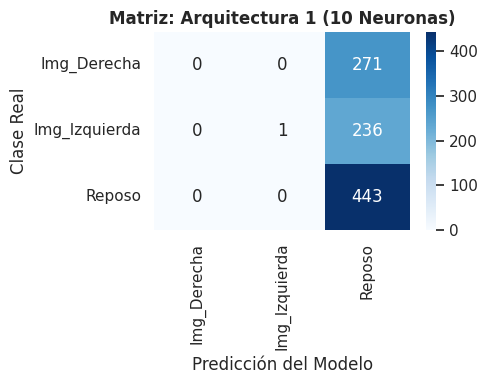


--- Resultados Arquitectura 2 (3 Capas, 50 Neuronas) ---
Reporte:
               precision    recall  f1-score   support

  Img_Derecha       0.32      0.17      0.22       271
Img_Izquierda       0.27      0.26      0.26       237
       Reposo       0.46      0.60      0.52       443

     accuracy                           0.39       951
    macro avg       0.35      0.34      0.33       951
 weighted avg       0.37      0.39      0.37       951



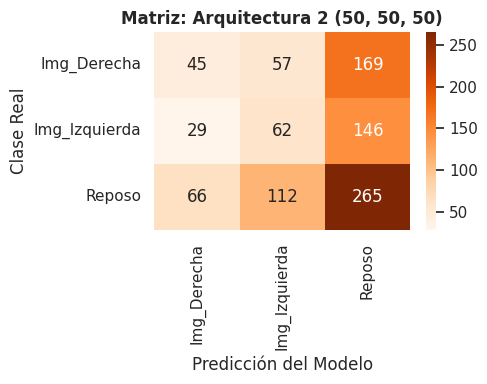


--- Resultados Arquitectura 3 (100 -> 50 -> 25 Neuronas) ---
Reporte:
               precision    recall  f1-score   support

  Img_Derecha       0.29      0.24      0.26       271
Img_Izquierda       0.29      0.18      0.22       237
       Reposo       0.46      0.60      0.52       443

     accuracy                           0.39       951
    macro avg       0.35      0.34      0.34       951
 weighted avg       0.37      0.39      0.37       951



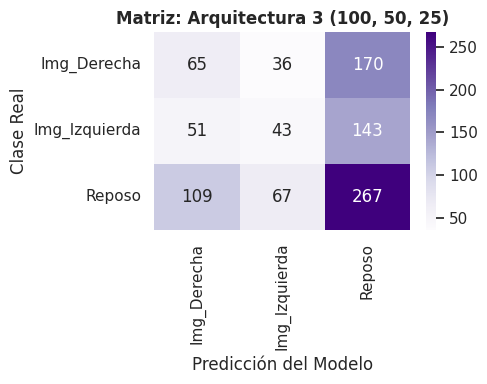

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

print("\n=== PUNTO B: 3 ARQUITECTURAS DIFERENTES ===")

# 1. Dividimos los datos (como en tu guía)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=40)

# Nombres de tus 3 clases para que el reporte y los ejes salgan limpios
target_names = ['Img_Derecha', 'Img_Izquierda', 'Reposo']

# =====================================================================
# --- Arquitectura 1 (Pocas neuronas) ---
# =====================================================================
mlp_1 = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=500, random_state=40)
mlp_1.fit(X_train, y_train)
predict_test_1 = mlp_1.predict(X_test)

print("\n--- Resultados Arquitectura 1 (1 Capa, 10 Neuronas) ---")
print("Reporte:")
print(classification_report(y_test, predict_test_1, target_names=target_names))

# Graficamos la Matriz de Confusión 1
cm_1 = confusion_matrix(y_test, predict_test_1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz: Arquitectura 1 (10 Neuronas)', fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()


# =====================================================================
# --- Arquitectura 2 (Profunda) ---
# =====================================================================
mlp_2 = MLPClassifier(hidden_layer_sizes=(50, 50, 50), activation='relu', solver='adam', max_iter=500, random_state=40)
mlp_2.fit(X_train, y_train)
predict_test_2 = mlp_2.predict(X_test)

print("\n--- Resultados Arquitectura 2 (3 Capas, 50 Neuronas) ---")
print("Reporte:")
print(classification_report(y_test, predict_test_2, target_names=target_names))

# Graficamos la Matriz de Confusión 2
cm_2 = confusion_matrix(y_test, predict_test_2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz: Arquitectura 2 (50, 50, 50)', fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()


# =====================================================================
# --- Arquitectura 3 (Embudo / Reducción) ---
# =====================================================================
mlp_3 = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam', max_iter=500, random_state=40)
mlp_3.fit(X_train, y_train)
predict_test_3 = mlp_3.predict(X_test)

print("\n--- Resultados Arquitectura 3 (100 -> 50 -> 25 Neuronas) ---")
print("Reporte:")
print(classification_report(y_test, predict_test_3, target_names=target_names))

# Graficamos la Matriz de Confusión 3
cm_3 = confusion_matrix(y_test, predict_test_3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz: Arquitectura 3 (100, 50, 25)', fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()


=== PUNTO C: SVM Y XGBOOST ===

--- Resultados SVM ---
Reporte:
                            precision    recall  f1-score   support

  Imaginación_Mano_Derecha       1.00      0.00      0.01       271
Imaginación_Mano_Izquierda       0.00      0.00      0.00       237
                    Reposo       0.47      1.00      0.64       443

                  accuracy                           0.47       951
                 macro avg       0.49      0.33      0.21       951
              weighted avg       0.50      0.47      0.30       951



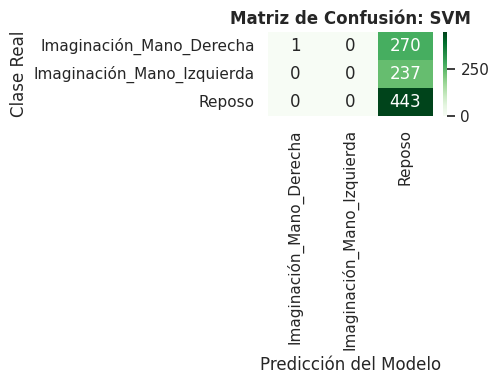


--- Resultados XGBoost ---
Reporte:
                            precision    recall  f1-score   support

  Imaginación_Mano_Derecha       0.25      0.13      0.17       271
Imaginación_Mano_Izquierda       0.29      0.22      0.25       237
                    Reposo       0.47      0.66      0.55       443

                  accuracy                           0.40       951
                 macro avg       0.34      0.34      0.32       951
              weighted avg       0.36      0.40      0.37       951



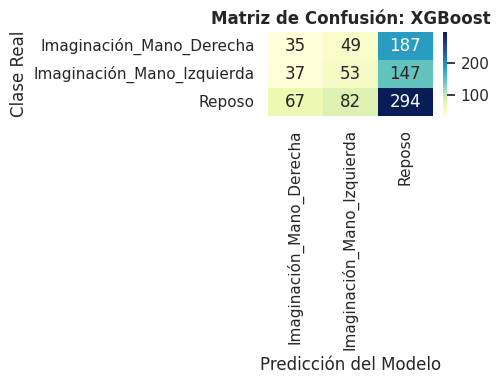

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("\n=== PUNTO C: SVM Y XGBOOST ===")

# =====================================================================
# --- Modelo SVM (Idéntico a tu cuaderno guía) ---
# =====================================================================
clf_svm = svm.SVC(gamma='auto', random_state=40)
clf_svm.fit(X_train, y_train)

predict_test_svm = clf_svm.predict(X_test)

# Extraemos las etiquetas en el orden exacto en que las guardó el SVM
target_names_svm = clf_svm.classes_

print("\n--- Resultados SVM ---")
print("Reporte:")
print(classification_report(y_test, predict_test_svm, target_names=target_names_svm))

# Graficamos la Matriz de Confusión para SVM
cm_svm = confusion_matrix(y_test, predict_test_svm, labels=target_names_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_svm, yticklabels=target_names_svm)
plt.title('Matriz de Confusión: SVM', fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()


# =====================================================================
# --- Modelo XGBoost ---
# =====================================================================
# XGBoost obliga a que las etiquetas sean números (ej: 0, 1, 2)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=40)
clf_xgb.fit(X_train, y_train_num)

# Predicciones de XGBoost (salen en números 0, 1, 2)
predict_test_xgb_num = clf_xgb.predict(X_test)

# Volvemos a convertir los números a texto (Reposo, Derecha, Izquierda)
predict_test_xgb = le.inverse_transform(predict_test_xgb_num)

# Extraemos las etiquetas en el orden exacto del LabelEncoder
target_names_xgb = le.classes_

print("\n--- Resultados XGBoost ---")
print("Reporte:")
print(classification_report(y_test, predict_test_xgb, target_names=target_names_xgb))

# Graficamos la Matriz de Confusión para XGBoost
cm_xgb = confusion_matrix(y_test, predict_test_xgb, labels=target_names_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=target_names_xgb, yticklabels=target_names_xgb)
plt.title('Matriz de Confusión: XGBoost', fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

#Bibliografia

- Hjorth, B. (1970). EEG analysis based on time domain properties. Electroencephalography and Clinical Neurophysiology, 29(3), 306–310. https://doi.org/10.1016/0013-4694(70)90143-4
- Oh, S.-H., & Lee, Y.-R. (2014). A Novel EEG Feature Extraction Method Using Hjorth Parameter. International Journal of Electronics and Electrical Engineering. (Semantic Scholar: 546864bcc8d88111893268eda6fc1a6cd74d1363).
- Rasjikin, N. et al. (2022). Discriminative Frequencies and Temporal EEG Segmentation in the Motor Imagery Classification Approach. Applied Sciences, 12(5), 2736. https://doi.org/10.3390/app12052736. diestros.
- Loza, C.A. et al. (2017). A Transform-Based Feature Extraction Approach for Motor Imagery Tasks Classification. IEEE Journal of Translational Engineering in Health and Medicine, 5. PMC4861551.
- McFarland, D.J. et al. (2017). EEG based zero-phase phase-locking value (PLV) and effects of spatial filtering during actual movement. Frontiers in Human Neuroscience, 11. PMC5406268.
- Brunner, C. et al. (2006). Phase-locking factor in a motor imagery Brain-Computer Interface. PubMed ID 23366525.
- Gupta, C.N. et al. (2021). Functional Connectivity Analysis in Motor-Imagery Brain Computer Interfaces. Frontiers in Human Neuroscience. PMC8555469.
- Richman, J.S. & Moorman, J.R. (2000). Physiological time-series analysis using approximate entropy and sample entropy. American Journal of Physiology – Heart and Circulatory Physiology, 278(6), H2039–H2049. https://doi.org/10.1152/ajpheart.2000.278.6.H2039.
- Zheng, C. et al. (2021). Prosthetic control system based on motor imagery. PubMed ID 34533381.
- Liu, H. et al. (2025). The Application of Entropy in Motor Imagery Paradigms of Brain–Computer Interfaces. PMC11853529.

